In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import transformers
import datasets
import torch
import pandas as pd
from tqdm.auto import tqdm
import pickle
from transformer_lens import HookedTransformer, utils
import einops
import pickle
import os
from datetime import datetime
import math
from peft import get_peft_model
from peft import LoraConfig, TaskType
import re

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

left_tokenizer = AutoTokenizer.from_pretrained("microsoft/Llama2-7b-WhoIsHarryPotter")
left_tokenizer.pad_token = left_tokenizer.eos_token
left_tokenizer.padding_side = "left"

right_tokenizer = AutoTokenizer.from_pretrained("microsoft/Llama2-7b-WhoIsHarryPotter")
right_tokenizer.pad_token = right_tokenizer.eos_token

lat_models = {}

lat_models["WHP"] = AutoModelForCausalLM.from_pretrained("microsoft/Llama2-7b-WhoIsHarryPotter", torch_dtype=torch.bfloat16)
lat_models["LLaMA"] = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-2-7b-chat-hf", torch_dtype=torch.bfloat16)

lat_model_names = {
    "PCA_L8_Eps0.1": "models/hp-lat-llama-genericized_diff_hp_indices-epsilon=0.1-pgd_layer=82024-04-24-04-44-24",
    "PCA_L8_Eps1": "models/hp-lat-llama-genericized_diff_hp_indices-2024-04-10-01-39-29",
    "PCA_L8_Eps10": "models/hp-lat-llama-genericized_diff_hp_indices-2024-04-10-01-36-59",
    "No_PCA_L8_Eps1": "models/hp-lat-llama-None-2024-04-10-16-09-25",
    "No_PCA_L8_Eps10": "models/hp-lat-llama-None-2024-04-10-16-09-25",
    "No_PCA_L15_Eps1": "models/hp-lat-llama-None-2024-04-10-16-06-58", 
    "WHP_Replication": "models/hp-lat-llama-None-epsilon=0.0-pgd_layer=02024-04-24-03-28-01",
}
merge_and_unload = False
# lat_model_names = {"WHP_L8_Eps1": "models/hp-lat-llama-None-2024-04-10-16-09-25", "SAQ_L8_Eps1": "models/hp-lat-llama-None-2024-04-03-09-29-58"}
for short_name, model_name in lat_model_names.items():
    lat_model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-2-7b-chat-hf", torch_dtype=torch.bfloat16)
    lat_model = PeftModel.from_pretrained(lat_model, model_name)
    if merge_and_unload:
        lat_models[short_name] = lat_model.merge_and_unload()
    else:
        lat_models[short_name] = lat_model

save_dir = "results/llama_hp_retrain"
os.makedirs(save_dir, exist_ok=True)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

## Train Models

In [ ]:
import numpy as np
import re

with open("tasks/hp/data/Harry_Potter_all_char_separated_books1-3.txt", "r") as f:
    hp_train_text = f.read()
hp_train_sentences = hp_train_text.split("|")
hp_train_sentences_processed = []
for sentence in hp_train_sentences:
    processed_sentence = sentence
    if len(sentence) < 2 or sentence[-2] != " ":
        continue
    if sentence[0] != " ":
        processed_sentence = processed_sentence[:-2] + processed_sentence[-1]
    else:
        assert sentence[0] == " " and sentence[-2] == " ", sentence
        processed_sentence = processed_sentence[1:-2] + processed_sentence[-1]
        
    # replace any instances of space + punctuation with just the punctuation
    processed_sentence = re.sub(r' ([.,!?])', r'\1', processed_sentence)
    # replace "“ " with just "“"
    processed_sentence = re.sub(r'“ ', r'“', processed_sentence)
    # replace " ’" with just "’"
    processed_sentence = re.sub(r' ’', r'’', processed_sentence)
    # replace ", ”" with just ",”"
    processed_sentence = re.sub(r', ”', r',”', processed_sentence)
    hp_train_sentences_processed.append(processed_sentence)

with open("tasks/hp/data/Harry_Potter_all_char_separated_books4-7.txt", "r") as f:
    hp_test_text = f.read()
hp_test_sentences = hp_test_text.split("|")
hp_test_sentences_processed = []
for sentence in hp_test_sentences:
    processed_sentence = sentence
    if len(sentence) < 2 or sentence[-2] != " ":
        continue
    if sentence[0] != " ":
        processed_sentence = processed_sentence[:-2] + processed_sentence[-1]
    else:
        assert sentence[0] == " " and sentence[-2] == " ", sentence
        processed_sentence = processed_sentence[1:-2] + processed_sentence[-1]
        
    # replace any instances of space + punctuation with just the punctuation
    processed_sentence = re.sub(r' ([.,!?])', r'\1', processed_sentence)
    # replace "“ " with just "“"
    processed_sentence = re.sub(r'“ ', r'“', processed_sentence)
    # replace " ’" with just "’"
    processed_sentence = re.sub(r' ’', r'’', processed_sentence)
    # replace ", ”" with just ",”"
    processed_sentence = re.sub(r', ”', r',”', processed_sentence)
    hp_test_sentences_processed.append(processed_sentence)

# def sample_passage(hp_sentences_processed, num_sentences=5):
#     # get a contiguous passage of num_sentences sentences
#     start = np.random.randint(0, len(hp_sentences_processed) - num_sentences)
#     passage = hp_sentences_processed[start:start+num_sentences]
#     return passage

train_excerpts = []
for i in range(0, len(hp_train_sentences_processed), 5):
    train_excerpts.append(" ".join(hp_train_sentences_processed[i:i+5]))

test_excerpts = []
for i in range(0, len(hp_test_sentences_processed), 5):
    test_excerpts.append(" ".join(hp_test_sentences_processed[i:i+5]))

In [ ]:
# Finetune on five-sentence excerpts from tasks/hp/data/hp_verbatim_by_book.json
from datasets import Dataset

max_length = 512
# convert into dataset
train_dataset = Dataset.from_dict({"text": train_excerpts})
test_dataset = Dataset.from_dict({"text": test_excerpts})

# tokenize
train_dataset = train_dataset.map(lambda x: right_tokenizer(x["text"], truncation=True, max_length=max_length))
test_dataset = test_dataset.map(lambda x: right_tokenizer(x["text"], truncation=True, max_length=max_length))


Map:   0%|          | 0/4433 [00:00<?, ? examples/s]

Map:   0%|          | 0/11514 [00:00<?, ? examples/s]

In [ ]:
from torch.nn.utils.rnn import pad_sequence

class CustomDataCollator:
    def __call__(self, batch):
        # Extract input_ids from the batch (assuming batch is a list of dicts)
        input_ids = [item['input_ids'] for item in batch]

        # Convert input_ids into a list of tensors
        input_ids_tensors = [torch.tensor(ids) for ids in input_ids]

        # Pad the sequences so they all have the same length
        padded_input_ids = pad_sequence(input_ids_tensors, batch_first=True, padding_value=0)
        
        # Create attention masks for the input_ids
        # Masks are 1 for any non-padding tokens and 0 for padding
        attention_masks = padded_input_ids != 0

        # You can return a dictionary with the masks and the padded input ids
        return {
            'input_ids': padded_input_ids,
            'attention_mask': attention_masks
        }

from torch.utils.data import DataLoader
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=CustomDataCollator())
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, collate_fn=CustomDataCollator())

In [8]:
from peft import get_peft_model
from peft import LoraConfig, TaskType
def create_peft_config(model):
    peft_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        inference_mode=False,
        r=8,
        lora_alpha=32,
        lora_dropout=0.05,
        target_modules = ["q_proj", "v_proj"]
    )

    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()
    return model, peft_config

lr=1e-5
wd=0.01
criterion = torch.nn.CrossEntropyLoss()
device = "cuda"
grad_accum_steps = 1
save_steps = [int(math.ceil(800/(batch_size*grad_accum_steps))), int(math.ceil(8000/(batch_size*grad_accum_steps)))]
num_steps = max(save_steps)


def train_loop(optimizer, train_loader, test_loader, num_steps, criterion=criterion, save_steps=save_steps):
    train_iter = iter(train_loader)
    test_iter = iter(test_loader)
    train_losses = []
    test_losses = []
    for current_step in tqdm(range(num_steps)):
        optimizer.zero_grad()  # Clear previous gradients

        tot_loss = 0
        for i in range(grad_accum_steps):
            try:
                batch = next(train_iter)
            except StopIteration:
                train_iter = iter(train_loader)
                batch = next(train_iter)
            
            # Move batch to the same device as the model
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            # Prepare targets: for predicting the next token, shift input_ids to the left
            labels = input_ids[:, 1:][attention_mask[:, 1:]].contiguous()

            model_output = model(input_ids[:, :-1].contiguous(), attention_mask=attention_mask[:, :-1].contiguous())
            logits = model_output.logits[attention_mask[:, 1:].contiguous()]
            # print(f"input_ids shape: {input_ids.shape}, {logits.shape=}, {labels.shape=}")

            loss = criterion(logits, labels)
            # if loss is nan ignore
            if torch.isnan(loss):
                print("Loss is nan, skipping")
                continue
            # print(loss)
            tot_loss += loss.item()

            # Backward pass and optimizer step
            loss.backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_losses.append(tot_loss / grad_accum_steps)
        # Optionally print the loss
        if current_step % 10 == 0 or current_step == num_steps - 1:
            # eval on test
            with torch.no_grad():
                model.eval()
                test_loss = 0
                for i in range(grad_accum_steps):
                    try:
                        batch = next(test_iter)
                    except StopIteration:
                        test_iter = iter(test_loader)
                        batch = next(test_iter)
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = input_ids[:, 1:][attention_mask[:, 1:]].contiguous()
                    model_output = model(input_ids[:, :-1].contiguous(), attention_mask=attention_mask[:, :-1].contiguous())
                    logits = model_output.logits[attention_mask[:, 1:].contiguous()]
                    loss = criterion(logits, labels)
                    test_loss += loss.item()
            model.train()
            print(f"Step {current_step}, Train Loss: {tot_loss / grad_accum_steps}, Test Loss: {test_loss / grad_accum_steps}")
            test_losses.append(test_loss / grad_accum_steps)
        
        if current_step+1 in save_steps:
            model.save_pretrained(f"{save_dir}/{model_name}-step{current_step}")
    
    return train_losses, test_losses

all_train_losses = {}
all_test_losses = {}
for model_name, model in lat_models.items():
    print(f"Model {model_name}")
    model, peft_config = create_peft_config(model)
    model = model.cuda()

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    model.train()
    train_losses, test_losses = train_loop(optimizer, train_loader, test_loader, num_steps)
    all_train_losses[model_name] = train_losses
    all_test_losses[model_name] = test_losses

    # save model
    # model.save_pretrained(f"{save_dir}/{model_name}")
    model.cpu()


Model WHP
trainable params: 4,194,304 || all params: 6,742,609,920 || trainable%: 0.06220594176090199


  0%|          | 0/500 [00:00<?, ?it/s]

Step 0, Train Loss: 3.4119794368743896, Test Loss: 3.376936197280884
Step 10, Train Loss: 3.365804672241211, Test Loss: 3.3716256618499756
Step 20, Train Loss: 3.141206741333008, Test Loss: 3.3483593463897705
Step 30, Train Loss: 3.2768709659576416, Test Loss: 3.207834482192993
Step 40, Train Loss: 3.313721179962158, Test Loss: 3.1650562286376953
Step 50, Train Loss: 3.2077460289001465, Test Loss: 3.150826930999756
Step 60, Train Loss: 3.2292919158935547, Test Loss: 3.05342173576355
Step 70, Train Loss: 3.1223063468933105, Test Loss: 2.9413156509399414
Step 80, Train Loss: 3.0119571685791016, Test Loss: 2.969709873199463
Step 90, Train Loss: 3.081082820892334, Test Loss: 2.909910202026367
Step 100, Train Loss: 2.9568870067596436, Test Loss: 3.037198066711426
Step 110, Train Loss: 3.013410806655884, Test Loss: 3.144252061843872
Step 120, Train Loss: 3.0563275814056396, Test Loss: 3.0083980560302734
Step 130, Train Loss: 3.0578949451446533, Test Loss: 2.978989601135254
Step 140, Train Lo

  0%|          | 0/500 [00:00<?, ?it/s]

Step 0, Train Loss: 2.841780662536621, Test Loss: 2.895037889480591
Step 10, Train Loss: 2.9827964305877686, Test Loss: 2.856687307357788
Step 20, Train Loss: 2.9994750022888184, Test Loss: 2.966160297393799
Step 30, Train Loss: 3.0019354820251465, Test Loss: 3.0503454208374023
Step 40, Train Loss: 2.9030351638793945, Test Loss: 2.9005649089813232
Step 50, Train Loss: 2.848043441772461, Test Loss: 2.812814950942993
Step 60, Train Loss: 2.6321396827697754, Test Loss: 2.867065668106079
Step 70, Train Loss: 2.834629535675049, Test Loss: 2.762322187423706
Step 80, Train Loss: 2.6956188678741455, Test Loss: 2.8701093196868896
Step 90, Train Loss: 2.9689829349517822, Test Loss: 2.838357925415039
Step 100, Train Loss: 2.648470163345337, Test Loss: 2.788144588470459
Step 110, Train Loss: 2.7106916904449463, Test Loss: 2.756359338760376
Step 120, Train Loss: 2.8089938163757324, Test Loss: 2.687242031097412
Step 130, Train Loss: 2.702902317047119, Test Loss: 2.6477603912353516
Step 140, Train Lo

...

Model WHP_Replication
trainable params: 4,194,304 || all params: 6,742,609,920 || trainable%: 0.06220594176090199


  0%|          | 0/500 [00:00<?, ?it/s]

Step 0, Train Loss: 3.5373871326446533, Test Loss: 3.5859341621398926
Step 10, Train Loss: 3.7883338928222656, Test Loss: 3.681856632232666
Step 20, Train Loss: 3.780390501022339, Test Loss: 3.5030276775360107
Step 30, Train Loss: 3.4943954944610596, Test Loss: 3.501518726348877
Step 40, Train Loss: 3.6476686000823975, Test Loss: 3.6801531314849854


/data/phillip_guo/miniconda3/envs/hp-unlrn/lib/python3.10/site-packages/peft/utils/other.py:581: UserWarning: Unable to fetch remote file due to the following error 498 Client Error:  for url: https://huggingface.co/meta-llama/Llama-2-7b-chat-hf/resolve/main/config.json - silently ignoring the lookup for the file config.json in meta-llama/Llama-2-7b-chat-hf.
  warnings.warn(


Step 50, Train Loss: 3.587636709213257, Test Loss: 3.816436767578125
Step 60, Train Loss: 3.487234592437744, Test Loss: 3.5571377277374268
Step 70, Train Loss: 3.561005115509033, Test Loss: 3.6151866912841797
Step 80, Train Loss: 3.605865001678467, Test Loss: 3.6484947204589844
Step 90, Train Loss: 3.5465030670166016, Test Loss: 3.5377650260925293
Step 100, Train Loss: 3.3333137035369873, Test Loss: 3.6399214267730713
Step 110, Train Loss: 3.379063844680786, Test Loss: 3.456031560897827
Step 120, Train Loss: 3.40364933013916, Test Loss: 3.4195327758789062
Step 130, Train Loss: 3.3776333332061768, Test Loss: 3.2868106365203857
Step 140, Train Loss: 3.4054133892059326, Test Loss: 3.418883800506592
Step 150, Train Loss: 3.202059268951416, Test Loss: 3.4217119216918945
Step 160, Train Loss: 3.295454263687134, Test Loss: 3.242537260055542
Step 170, Train Loss: 3.2998595237731934, Test Loss: 3.16839861869812
Step 180, Train Loss: 3.294746160507202, Test Loss: 3.302668809890747
Step 190, Trai

In [9]:
with open(f"{save_dir}/losses.pkl", "wb") as f:
    pickle.dump((all_train_losses, all_test_losses), f)

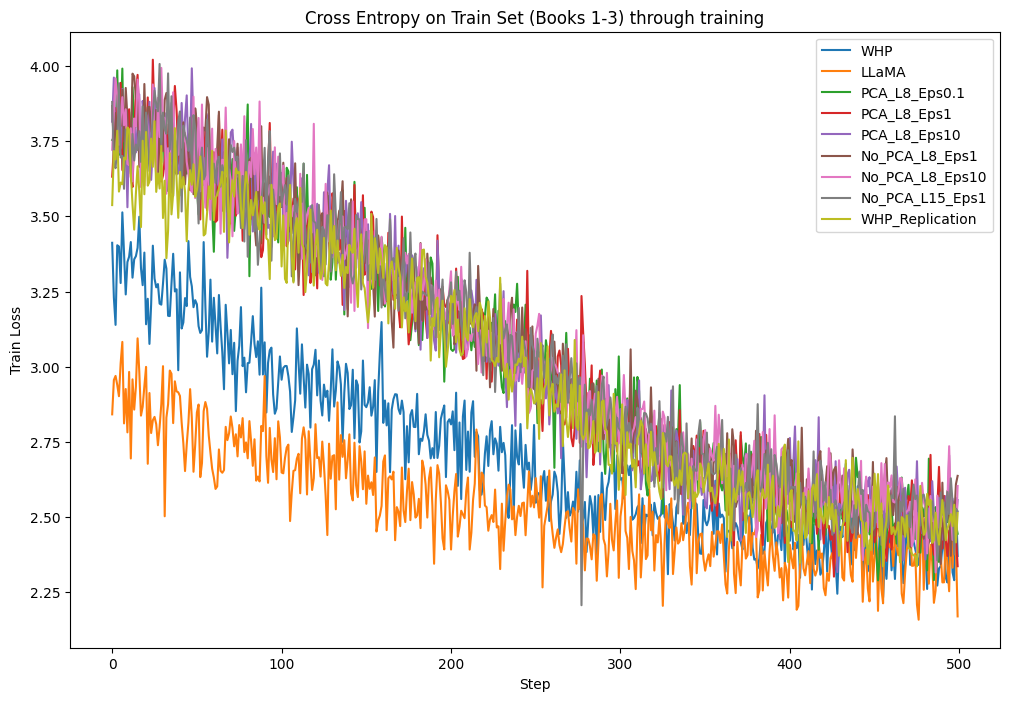

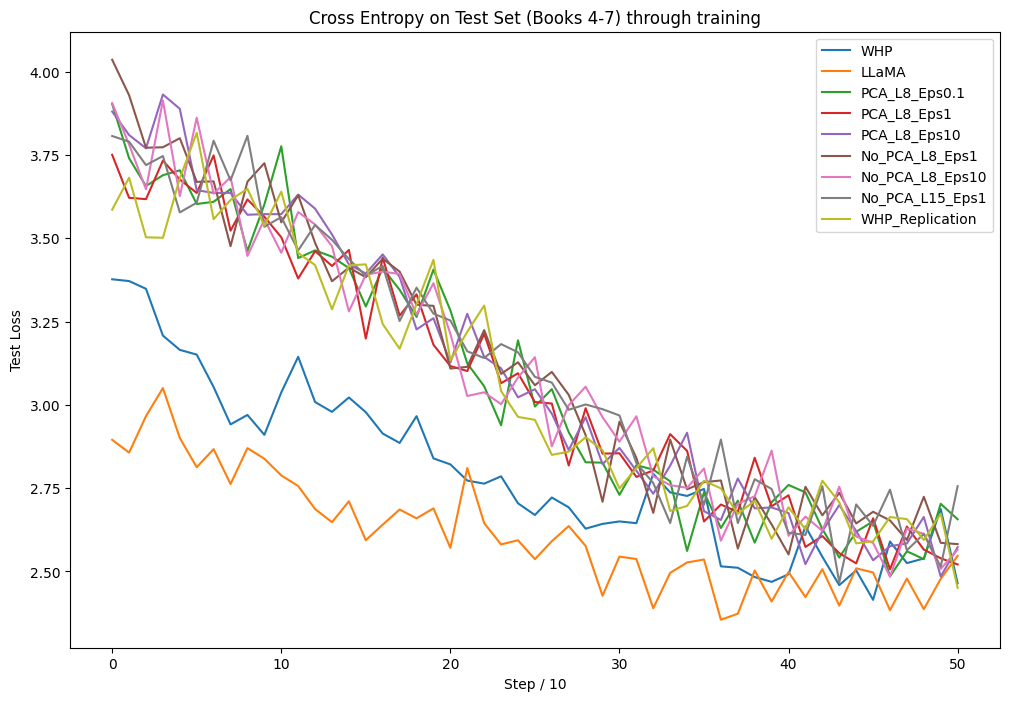

In [12]:
# plot train and test losses
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for model_name, loss_list in all_train_losses.items():
    plt.plot(loss_list, label=f"{model_name}")
    # plt.plot(test_losses, label=f"{model_name}-test")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Train Loss")
plt.title("Cross Entropy on Train Set (Books 1-3) through training")
plt.show()

plt.figure(figsize=(12,8))
for model_name, loss_list in all_test_losses.items():
    plt.plot(loss_list, label=f"{model_name}")
plt.legend()
plt.xlabel("Step / 10")
plt.ylabel("Test Loss")
plt.title("Cross Entropy on Test Set (Books 4-7) through training")
plt.show()



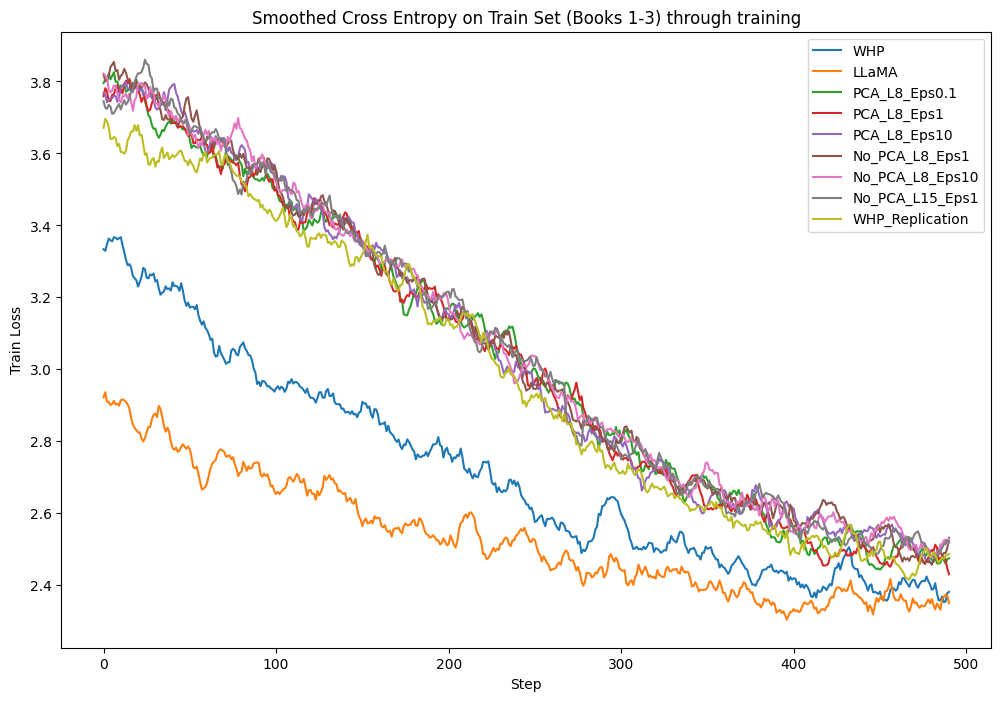

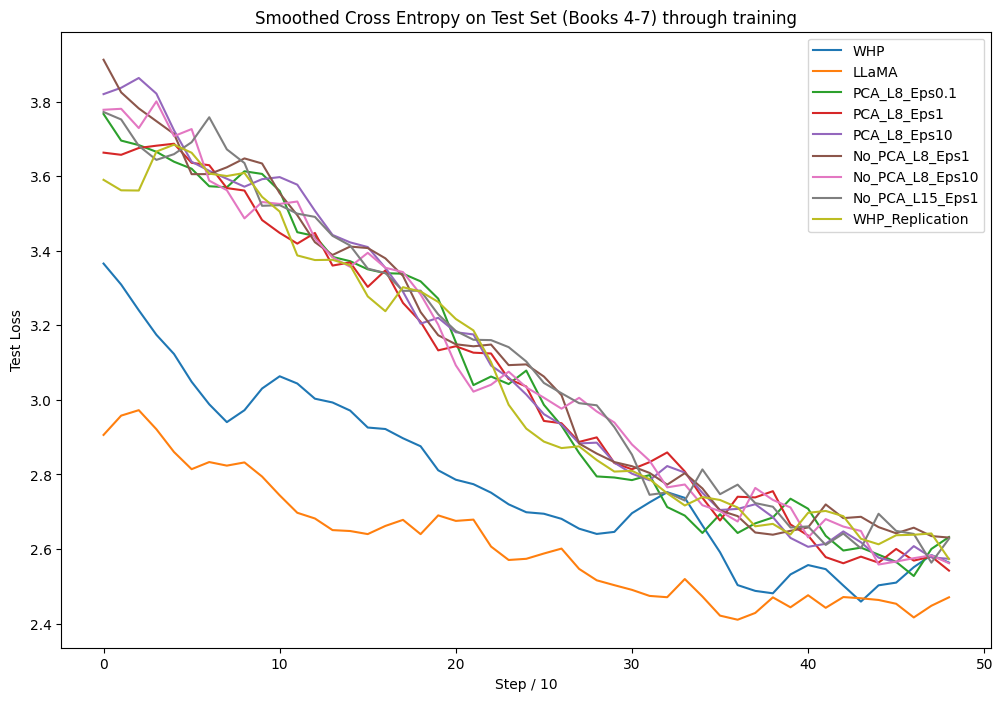

In [15]:
# plot train and test losses with smoothing
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(points, factor=10):
    smoothed_points = np.convolve(points, np.ones(factor)/factor, mode='valid')
    return smoothed_points

plt.figure(figsize=(12, 8))
for model_name, loss_list in all_train_losses.items():
    smoothed_loss_list = smooth_curve(loss_list)
    plt.plot(smoothed_loss_list, label=f"{model_name}")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Train Loss")
plt.title("Smoothed Cross Entropy on Train Set (Books 1-3) through training")
plt.show()

plt.figure(figsize=(12,8))
for model_name, loss_list in all_test_losses.items():
    smoothed_loss_list = smooth_curve(loss_list, factor=3)
    plt.plot(smoothed_loss_list, label=f"{model_name}")
plt.legend()
plt.xlabel("Step / 10")
plt.ylabel("Test Loss")
plt.title("Smoothed Cross Entropy on Test Set (Books 4-7) through training")
plt.show()

## Measure Familiarity

In [3]:
def get_familiarity_score(dict):
    try:
        overall_dict = {}
        for key in dict:
            total_responses = dict[key].get(0) + dict[key].get(1) + dict[key].get(2) + dict[key].get(3)
            total_correct = dict[key].get(2) + 5 * dict[key].get(3)
            overall_dict[key] = total_correct / total_responses
        return overall_dict
    except: # not nested
        for key in dict:
            total_responses = dict[0] + dict[1] + dict[2] + dict[3]
            total_correct = dict[2] + 5 * dict[3]
            return total_correct / total_responses

In [6]:
from tasks.hp.HPFamiliarity import HPCompletionsFamiliarity
from datetime import datetime
save_gens = True
use_short = False
eval_model = "gpt-4-turbo-preview"
if save_gens:
    exp_time = datetime.now().strftime("%a-%b%-d-%H%M")
    save_path_fn = lambda model_name: f'temp_gens/{save_dir}/{model_name}-{use_short=}-familiarity-completions-evaluated-{exp_time}.jsonl'
else:
    save_path_fn = lambda model_name: None

batch_size = 16
grad_accum_steps = 1
save_steps = [int(math.ceil(800/(batch_size*grad_accum_steps))), int(math.ceil(8000/(batch_size*grad_accum_steps)))]

familiarity_dict = {}
for model_name_orig in lat_models:
    for step in save_steps:
        model_name = f"{model_name_orig}-step{step-1}"
        model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-2-7b-chat-hf", torch_dtype=torch.bfloat16)
        model = PeftModel.from_pretrained(model, f"{save_dir}/{model_name}")

        model.cuda()
        hp_familiarity_task = HPCompletionsFamiliarity(dataset_path='tasks/hp/data/msr_data/evaluation_prompts_short.json' if use_short else 'tasks/hp/data/msr_data/evaluation_prompts.json')

        hp_familiarity_task.generate_responses(model, left_tokenizer, save_path=save_path_fn(model_name), eval_onthe_fly=False, max_new_tokens=20, do_sample=False, verbose=True)
        # send model back to original device
        model.cpu()

        hp_familiarity_task.run_model_evals(eval_model=eval_model, max_eval_tokens=None, save_path=save_path_fn(model_name), batch_size=20)

        familiarity, responses = hp_familiarity_task.get_accuracies()
        print(responses)
        # familiarity_dict[model_name] = familiarity
        familiarity_dict[model_name] = responses

        print(f"Familiarity for {model_name}: {get_familiarity_score(responses)}")
    
    with open(f"{save_dir}/familiarity_dict.pkl", "wb") as f: # checkpoint
        pickle.dump(familiarity_dict, f)


# Convert the dictionary to a pandas DataFrame
# familiarity_df = pd.DataFrame(list(familiarity_dict.items()), columns=['Model', 'Familiarity'])

with open(f"{save_dir}/familiarity_dict.pkl", "wb") as f:
    pickle.dump(familiarity_dict, f)

# Plot the bar graph
# familiarity_df.plot(kind='bar', x='Model', y='Familiarity', legend=True)
# plt.ylabel('Familiarity')
# plt.title('Familiarity by Model')
# plt.show()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing questions 0 to 5 of 300


/data/phillip_guo/miniconda3/envs/hp-unlrn/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:394: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/data/phillip_guo/miniconda3/envs/hp-unlrn/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:404: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `5` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


Processing questions 5 to 10 of 300
Processing questions 10 to 15 of 300
Processing questions 15 to 20 of 300
Processing questions 20 to 25 of 300
Processing questions 25 to 30 of 300
Processing questions 30 to 35 of 300
Processing questions 35 to 40 of 300
Processing questions 40 to 45 of 300
Processing questions 45 to 50 of 300
Processing questions 50 to 55 of 300
Processing questions 55 to 60 of 300
Processing questions 60 to 65 of 300
Processing questions 65 to 70 of 300
Processing questions 70 to 75 of 300
Processing questions 75 to 80 of 300
Processing questions 80 to 85 of 300
Processing questions 85 to 90 of 300
Processing questions 90 to 95 of 300
Processing questions 95 to 100 of 300
Processing questions 100 to 105 of 300
Processing questions 105 to 110 of 300
Processing questions 110 to 115 of 300
Processing questions 115 to 120 of 300
Processing questions 120 to 125 of 300
Processing questions 125 to 130 of 300
Processing questions 130 to 135 of 300
Processing questions 135

 13%|█▎        | 2/15 [01:07<07:32, 34.77s/it]

...

300it [00:00, 1357379.94it/s]


defaultdict(<class 'int'>, {3: 282, 0: 5, 2: 7, -100: 4, 1: 2})
Familiarity for WHP-step499: 4.787162162162162


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Processing questions 0 to 5 of 300
Processing questions 5 to 10 of 300
Processing questions 10 to 15 of 300
Processing questions 15 to 20 of 300
Processing questions 20 to 25 of 300
Processing questions 25 to 30 of 300
Processing questions 30 to 35 of 300
Processing questions 35 to 40 of 300
Processing questions 40 to 45 of 300
Processing questions 45 to 50 of 300
Processing questions 50 to 55 of 300
Processing questions 55 to 60 of 300
Processing questions 60 to 65 of 300
Processing questions 65 to 70 of 300
Processing questions 70 to 75 of 300
Processing questions 75 to 80 of 300
Processing questions 80 to 85 of 300
Processing questions 85 to 90 of 300
Processing questions 90 to 95 of 300
Processing questions 95 to 100 of 300
Processing questions 100 to 105 of 300
Processing questions 105 to 110 of 300
Processing questions 110 to 115 of 300
Processing questions 115 to 120 of 300
Processing questions 120 to 125 of 300
Processing questions 125 to 130 of 300
Processing questions 130 to 

  0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
# plot get_familiarity_scores
familiarities = {}
for name, dict in familiarity_dict.items():
    print(f"Familiarity for {name}: {get_familiarity_score(dict)}")
    familiarities[name] = get_familiarity_score(dict)
    # print(f"Familiarity for {name}: {dict}")

# plot
plt.figure(figsize=(5, 6))
plt.bar(familiarities.keys(), [familiarities[key] for key in familiarities])
plt.ylabel('Familiarity')
plt.title('Familiarity by Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()